# Exploratory Data Analysis: Russian Toxic Comments Dataset

This notebook explores the Kaggle Russian Language Toxic Comments dataset.  
**Goal:** Understand data distribution, comment characteristics, and vocabulary patterns before modeling.

In [7]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# Allow importing from src/
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12
pd.set_option("display.max_colwidth", 200)

print("Setup complete.")

Setup complete.


## 1. Load Data

In [8]:
df = pd.read_csv("../data/labeled.csv")
df["toxic"] = df["toxic"].astype(int)

print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nFirst 10 rows:")
df.head(10)

Shape: (14412, 2)

Dtypes:
comment    object
toxic       int64
dtype: object

Missing values:
comment    0
toxic      0
dtype: int64

Duplicate rows: 0

First 10 rows:


,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1
1,"Хохлы, это отдушина затюканого россиянина, мол, вон, а у хохлов еще хуже. Если бы хохлов не было, кисель их бы придумал.\n",1
2,Собаке - собачья смерть\n,1
3,"Страницу обнови, дебил. Это тоже не оскорбление, а доказанный факт - не-дебил про себя во множественном числе писать не будет. Или мы в тебя верим - это ты и твои воображаемые друзья?\n",1
4,"тебя не убедил 6-страничный пдф в том, что Скрипалей отравила Россия? Анализировать и думать пытаешься? Ватник что ли?)\n",1
5,Для каких стан является эталоном современная система здравоохранения РФ? Для Зимбабве? Ты тупой? хохлы\n,1
6,"В шапке были ссылки на инфу по текущему фильму марвел. Эти ссылки были заменены на фразу Репортим брипидора, игнорируем его посты. Если этого недостаточно, чтобы понять, что модератор абсолютный н...",0
7,УПАД Т! ТАМ НЕЛЬЗЯ СТРОИТЬ! ТЕХНОЛОГИЙ НЕТ! РАЗВОРУЮТ КАК ВСЕГДА! УЖЕ ТРЕЩИНАМИ ПОШ Л! ТУПЫЕ КИТАЗЫ НЕ МОГУТ НИЧЕГО НОРМАЛЬНО СДЕЛАТЬ!\n,1
8,"Ебать тебя разносит, шизик.\n",1
9,"Обосрался, сиди обтекай\n",1


## 2. Class Distribution

Class distribution:
  0 (non-toxic): 9586 (66.5%)
  1 (toxic): 4826 (33.5%)
  Imbalance ratio: 1:2.0


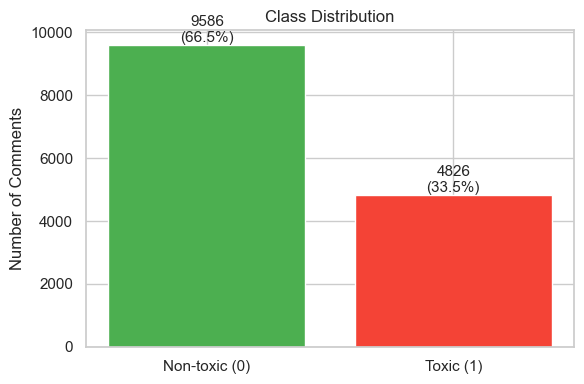

In [9]:
counts = df["toxic"].value_counts().sort_index()
total = len(df)

print("Class distribution:")
for label, count in counts.items():
    print(f"  {label} ({'toxic' if label == 1 else 'non-toxic'}): {count} ({count/total*100:.1f}%)")
print(f"  Imbalance ratio: 1:{counts[0]/counts[1]:.1f}")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Non-toxic (0)", "Toxic (1)"], counts.values, color=["#4CAF50", "#F44336"])
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{count}\n({count/total*100:.1f}%)", ha="center", fontsize=11)
ax.set_ylabel("Number of Comments")
ax.set_title("Class Distribution")
plt.tight_layout()
plt.show()

## 3. Comment Length Analysis (Characters)

Character length statistics by class:
        count   mean    std   min   25%    50%    75%     max
toxic                                                        
0      9586.0  194.2  274.8  21.0  66.0  118.0  223.0  7404.0
1      4826.0  141.4  261.8  21.0  45.0   76.0  140.0  5218.0


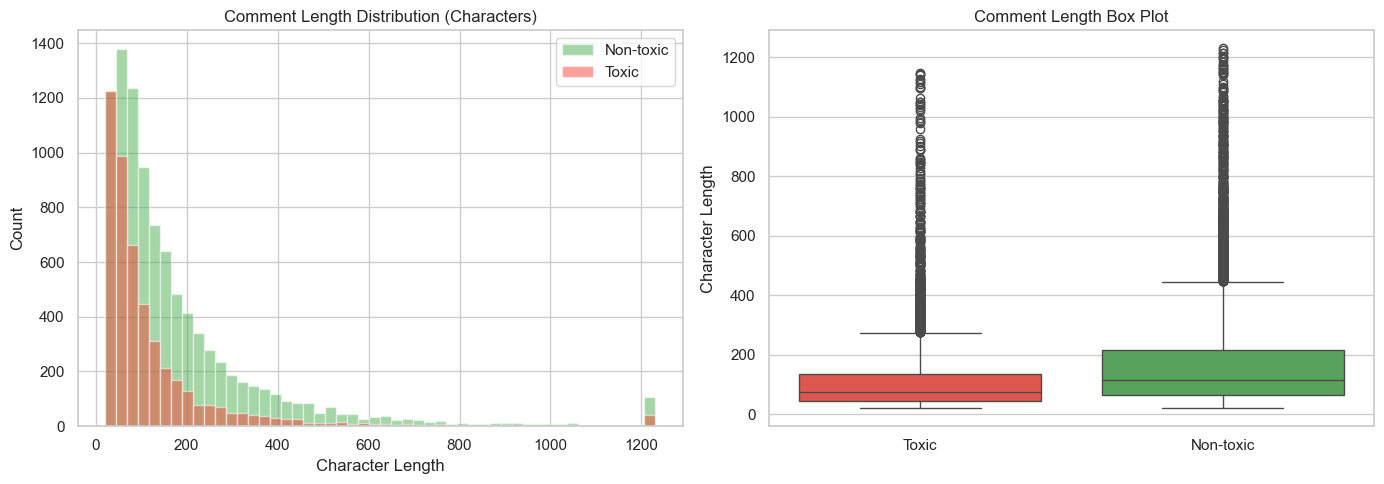

In [10]:
df["char_len"] = df["comment"].astype(str).str.len()

print("Character length statistics by class:")
print(df.groupby("toxic")["char_len"].describe().round(1))

# Histograms
clip_99 = df["char_len"].quantile(0.99)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlapping histogram
for label, color, name in [(0, "#4CAF50", "Non-toxic"), (1, "#F44336", "Toxic")]:
    subset = df[df["toxic"] == label]["char_len"]
    axes[0].hist(subset.clip(upper=clip_99), bins=50, alpha=0.5, color=color, label=name)
axes[0].set_xlabel("Character Length")
axes[0].set_ylabel("Count")
axes[0].set_title("Comment Length Distribution (Characters)")
axes[0].legend()

# Box plot
filtered = df[df["char_len"] <= clip_99].copy()
filtered["class"] = filtered["toxic"].map({0: "Non-toxic", 1: "Toxic"})
sns.boxplot(data=filtered, x="class", y="char_len", ax=axes[1],
            palette={"Non-toxic": "#4CAF50", "Toxic": "#F44336"}, hue="class", legend=False)
axes[1].set_xlabel("")
axes[1].set_ylabel("Character Length")
axes[1].set_title("Comment Length Box Plot")

plt.tight_layout()
plt.show()

## 4. Comment Length Analysis (Tokens)

Token count statistics by class:
        count  mean   std  min   25%   50%   75%     max
toxic                                                   
0      9586.0  30.7  40.8  2.0  11.0  19.0  36.0  1012.0
1      4826.0  22.4  42.1  1.0   7.0  12.0  23.0  1078.0


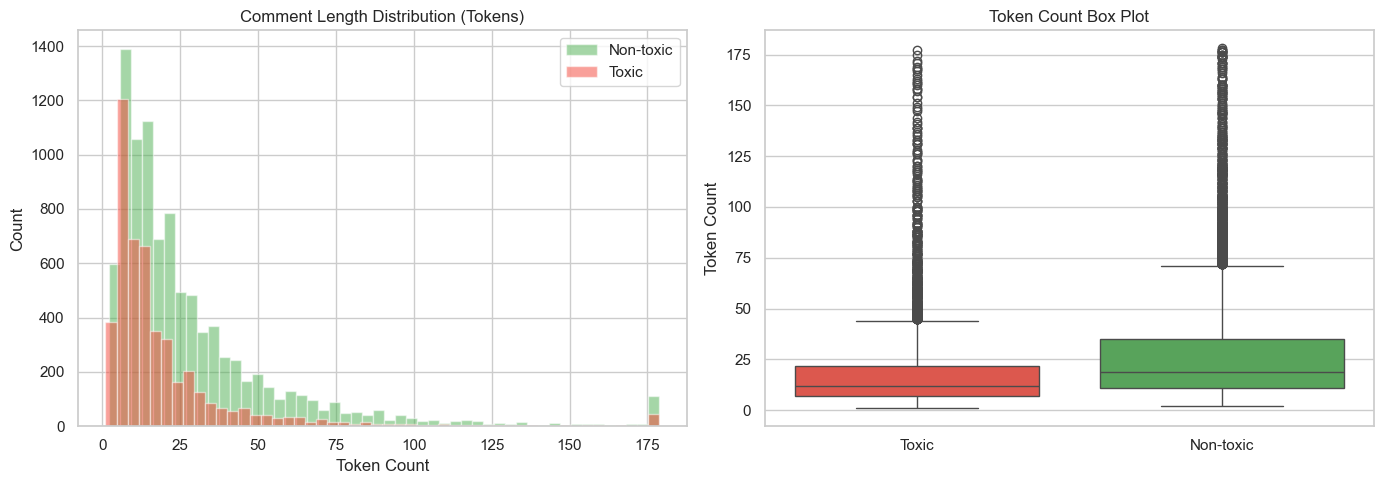

In [11]:
df["token_count"] = df["comment"].astype(str).str.split().apply(len)

print("Token count statistics by class:")
print(df.groupby("toxic")["token_count"].describe().round(1))

clip_99_tok = df["token_count"].quantile(0.99)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, name in [(0, "#4CAF50", "Non-toxic"), (1, "#F44336", "Toxic")]:
    subset = df[df["toxic"] == label]["token_count"]
    axes[0].hist(subset.clip(upper=clip_99_tok), bins=50, alpha=0.5, color=color, label=name)
axes[0].set_xlabel("Token Count")
axes[0].set_ylabel("Count")
axes[0].set_title("Comment Length Distribution (Tokens)")
axes[0].legend()

filtered_tok = df[df["token_count"] <= clip_99_tok].copy()
filtered_tok["class"] = filtered_tok["toxic"].map({0: "Non-toxic", 1: "Toxic"})
sns.boxplot(data=filtered_tok, x="class", y="token_count", ax=axes[1],
            palette={"Non-toxic": "#4CAF50", "Toxic": "#F44336"}, hue="class", legend=False)
axes[1].set_xlabel("")
axes[1].set_ylabel("Token Count")
axes[1].set_title("Token Count Box Plot")

plt.tight_layout()
plt.show()

## 5. Word Frequency Analysis

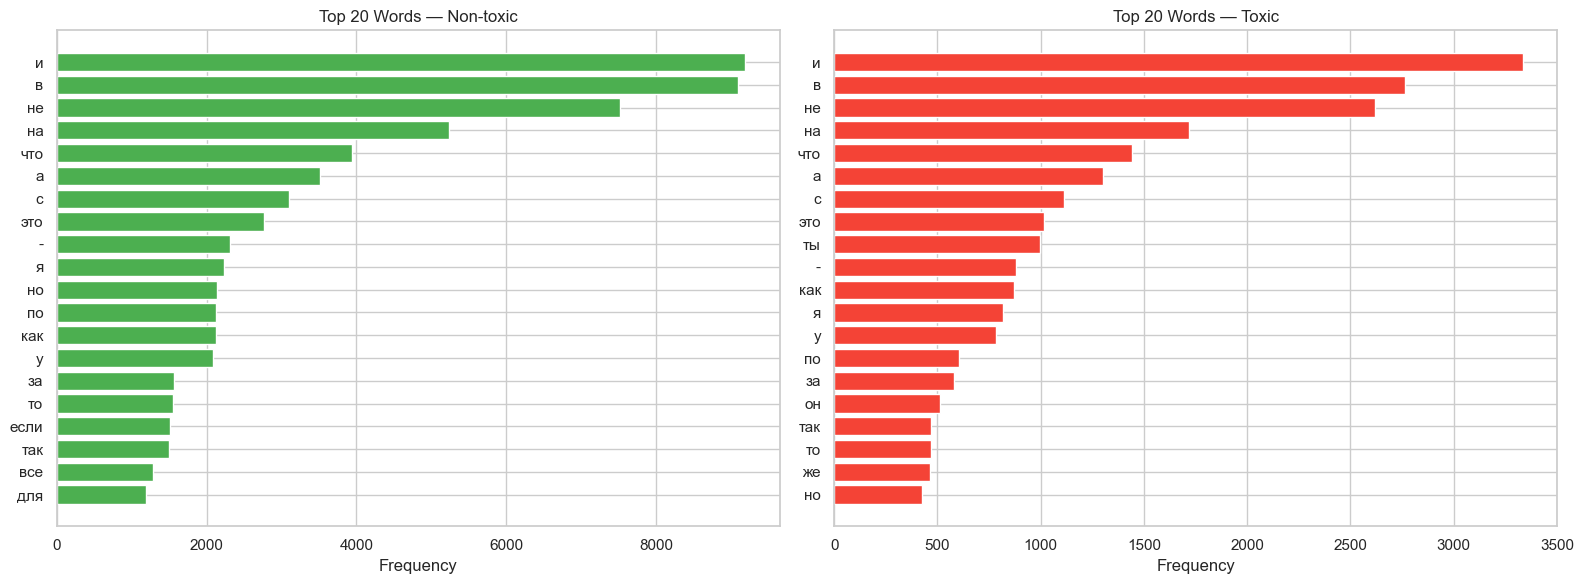

In [12]:
def get_word_counts(texts):
    words = []
    for text in texts:
        words.extend(str(text).lower().split())
    return Counter(words)

toxic_words = get_word_counts(df[df["toxic"] == 1]["comment"])
nontoxic_words = get_word_counts(df[df["toxic"] == 0]["comment"])

top_n = 20
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Non-toxic top words
nontoxic_top = nontoxic_words.most_common(top_n)
axes[0].barh([w for w, _ in nontoxic_top][::-1], [c for _, c in nontoxic_top][::-1], color="#4CAF50")
axes[0].set_title(f"Top {top_n} Words — Non-toxic")
axes[0].set_xlabel("Frequency")

# Toxic top words
toxic_top = toxic_words.most_common(top_n)
axes[1].barh([w for w, _ in toxic_top][::-1], [c for _, c in toxic_top][::-1], color="#F44336")
axes[1].set_title(f"Top {top_n} Words — Toxic")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

## 6. Word Clouds

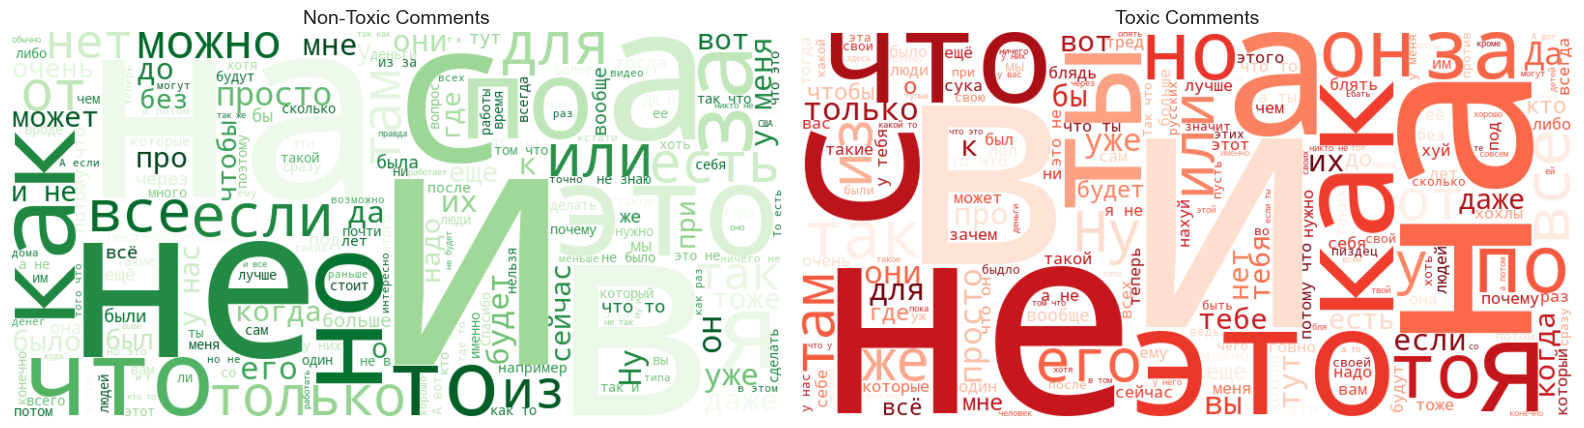

In [13]:
# Note: If Cyrillic text renders as boxes, set font_path to a Cyrillic-capable font, e.g.:
# font_path="/System/Library/Fonts/Supplemental/Arial Unicode.ttf"  # macOS
# font_path="/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"       # Linux

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (label, title, cmap) in enumerate([(0, "Non-Toxic Comments", "Greens"), (1, "Toxic Comments", "Reds")]):
    text = " ".join(df[df["toxic"] == label]["comment"].astype(str).tolist())
    wc = WordCloud(width=800, height=400, background_color="white",
                   max_words=200, colormap=cmap).generate(text)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(title, fontsize=14)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## 7. Sample Comments

In [14]:
print("=" * 80)
print("SAMPLE NON-TOXIC COMMENTS (5 random)")
print("=" * 80)
for i, row in df[df["toxic"] == 0].sample(5, random_state=42).iterrows():
    print(f"\n[{i}] {row['comment'][:300]}")

print("\n" + "=" * 80)
print("SAMPLE TOXIC COMMENTS (5 random)")
print("=" * 80)
for i, row in df[df["toxic"] == 1].sample(5, random_state=42).iterrows():
    print(f"\n[{i}] {row['comment'][:300]}")

SAMPLE NON-TOXIC COMMENTS (5 random)

[8481] Где этот город, в котором за 60к можно работать на одной работе? Тут на 3 ишачишь, и 50к еле еле


[7374] У кого-то было ооочень много свободного времени


[153] Ага, но если посмотреть на историю региона чуть раньше то будет так: Русские подружились с черкесами. Русские перестали дружить с черкесами, после их нападений. Соседи осознают, что какая-то хрень пошла, просят защиты у России. Черкесы и чеченцы начинают грабят соседей и входят во вкус, формируется 

[10928] почему? Логика следующая - в фокусе центр,а чем дальше от зрителя и чем ближе к зрителю,то расфокус увеличивается


[3770] Проблема скорее во взаимопонимании. Они же могут все обсудить, все всех устроит, у них будет какой-то план и они будут его придерживаться, и все равно жаловаться. Люди должны быть адекватные.


SAMPLE TOXIC COMMENTS (5 random)

[975] Ебать, кто смотрит сыромятникова?? Где еще можно найти настолько отталкивающий тембр голоса и манеру говорить?? Блять а полезн

## 8. Summary Statistics

In [15]:
summary = pd.DataFrame({
    "Non-toxic": [
        len(df[df["toxic"] == 0]),
        f"{len(df[df['toxic'] == 0]) / len(df) * 100:.1f}%",
        df[df["toxic"] == 0]["char_len"].mean().round(1),
        df[df["toxic"] == 0]["char_len"].median(),
        df[df["toxic"] == 0]["token_count"].mean().round(1),
        df[df["toxic"] == 0]["token_count"].median(),
    ],
    "Toxic": [
        len(df[df["toxic"] == 1]),
        f"{len(df[df['toxic'] == 1]) / len(df) * 100:.1f}%",
        df[df["toxic"] == 1]["char_len"].mean().round(1),
        df[df["toxic"] == 1]["char_len"].median(),
        df[df["toxic"] == 1]["token_count"].mean().round(1),
        df[df["toxic"] == 1]["token_count"].median(),
    ],
    "Total": [
        len(df),
        "100%",
        df["char_len"].mean().round(1),
        df["char_len"].median(),
        df["token_count"].mean().round(1),
        df["token_count"].median(),
    ],
}, index=["Count", "Percentage", "Mean char length", "Median char length",
          "Mean token count", "Median token count"])

summary

,Non-toxic,Toxic,Total
Count,9586,4826,14412
Percentage,66.5%,33.5%,100%
Mean char length,194.2,141.4,176.5
Median char length,118.0,76.0,101.0
Mean token count,30.7,22.4,27.9
Median token count,19.0,12.0,16.0


## 9. Key Takeaways

**Fill in after running the notebook:**

- **Dataset size:** ~27,856 comments
- **Class balance:** The dataset is imbalanced — non-toxic comments outnumber toxic ones (check exact ratio above)
- **Comment lengths:** Compare mean/median lengths between classes — are toxic comments shorter or longer?
- **Vocabulary:** Top words in both classes are dominated by common Russian stopwords. The toxic class likely shows distinctive profanity and slurs
- **Data quality issues:** Note any NaN values, duplicates, or encoding problems found above
- **Implications for modeling:** Class imbalance may require stratified sampling or class weights during training